1. Імпорти

In [24]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

2. Завантаження даних (streaming, safe)

In [25]:
FILE_PATH = "../data/raw/train_complete.jsonl"

sample_data = []
MAX_JAVA = 50000  # можна змінити

with open(FILE_PATH, "r", encoding="utf-8") as f:
    for line in tqdm(f):
        row = json.loads(line)

        # тільки Java
        if row.get("lang") == "java":
            sample_data.append(row)

            if len(sample_data) >= MAX_JAVA:
                break

df = pd.DataFrame(sample_data)

print("Shape:", df.shape)
df.head()

141259it [04:46, 493.18it/s] 


Shape: (30230, 22)


,patch,oldf,hunk,msg,ids,repo,ghid,old,new,lang,...,user_id,user_login,created_at,name,repo_aco,sys_aco,pkg_aco,repo_rso,sys_rso,pkg_rso
0,"@@ -13,21 +13,17 @@\n \n public class OnThisDa...",package org.wikipedia.feed.onthisday;\n\nimpor...,"@@ -16,7 +16,7 @@ public class OnThisDayActivi...",Would it be better if add annotations to the p...,"[20887, 3e39aa16bb601c90e73b98249a9dcd77f17d51...",wikimedia/apps-android-wikipedia,1602,"public static final String YEAR = ""year"";...","public static final String YEAR = ""year"";...",java,...,2435576,cooltey,1600976839000,Cooltey Feng,0.008198,0.010611,0.053333,0.195692,0.198473,0.431818
1,"@@ -0,0 +1,62 @@\n+/*\n+ * Licensed to the Apa...",/*\n * Licensed to the Apache Software Foundat...,"@@ -35,6 +35,11 @@ public class TailStateRoute...","if needToPrintMessage is true , I think it is ...","[47942, 5c1fdb73465ab605ad337384574b6bce7dccc0...",apache/dubbo,9424,}\n @Override\n public URL getUrl...,}\n+ @Override\n+ public void setNe...,java,...,8599441,qinliujie,1639708937000,qinliujie,0.006997,0.006154,0.000000,0.014902,0.011747,0.000000
2,"@@ -84,4 +84,58 @@ public static boolean isLam...",/**\n * Licensed to the Apache Software Founda...,"@@ -97,6 +97,14 @@ public class FunctionUtils ...",This looks like a good way of doing it to make...,"[95115, 14e3d7405054e5010676d3689f9d1272c09a0b...",apache/flink,113,\t\t\t\t\t// check if class is a lambda funct...,\t\t\t\t\t// check if class is a lambda funct...,java,...,1727146,StephanEwen,1409757448000,Stephan Ewen,0.022218,0.424242,0.500000,0.563218,0.700000,1.000000
3,"@@ -77,8 +74,7 @@ public ProcedurePartitionInf...",/* This file is part of VoltDB.\n * Copyright ...,"@@ -74,7 +74,7 @@ public class CatalogContext ...",Can it be final?,"[81094, 7d3d9afb460d277f419ec81e3fd3ad59f1f724...",VoltDB/voltdb,4723,private final byte[] deploymentBytes;\n ...,private final byte[] deploymentBytes;\n ...,java,...,1675698,akhanzode,1500659583000,Anish Khanzode,0.054933,0.061139,0.059734,0.098339,0.100373,0.122477
4,"@@ -292,12 +288,11 @@ public static String get...","/*\n* Copyright (c) 2018, WSO2 Inc. (http://w...","@@ -288,11 +288,11 @@ public class MimeUtil {\...","shall we use ""log"" instead of ""LOG"" private st...","[209831, 96fcabaca154f22d01a8a43dc49c156481803...",ballerina-platform/ballerina-lang,4722,if (isNotNullAndEmpty(returnValue)) {...,if (isNotNullAndEmpty(returnValue)) {...,java,...,11239305,Bhashinee,1519007203000,Bhashinee,0.000104,0.000000,0.000000,0.001109,0.000000,0.000000


3. Подивитись колонки

In [26]:
print(df.columns)

Index(['patch', 'oldf', 'hunk', 'msg', 'ids', 'repo', 'ghid', 'old', 'new',
       'lang', 'review_id', 'file', 'user_id', 'user_login', 'created_at',
       'name', 'repo_aco', 'sys_aco', 'pkg_aco', 'repo_rso', 'sys_rso',
       'pkg_rso'],
      dtype='str')


4. Базова очистка

In [27]:
df["msg"] = df["msg"].fillna("")
df["patch"] = df["patch"].fillna("")
df["new"] = df["new"].fillna("")

5. Feature Engineering

довжина коментаря

In [28]:
df["msg_len"] = df["msg"].str.len()

довжина коду

In [29]:
df["code_len"] = df["new"].str.len()

довжина патчу

In [30]:
df["patch_len"] = df["patch"].str.len()

додані / видалені рядки

In [31]:
df["added_lines"] = df["patch"].str.count(r"\+")
df["removed_lines"] = df["patch"].str.count(r"\-")

6. Статистика

In [32]:
df[["msg_len", "code_len", "patch_len", "added_lines", "removed_lines"]].describe()

,msg_len,code_len,patch_len,added_lines,removed_lines
count,30230.000000,30230.000000,30230.000000,30230.000000,30230.000000
mean,114.443235,338.121403,1012.089547,17.676811,4.707774
std,105.086241,160.868277,1945.853289,45.436354,16.941017
min,3.000000,9.000000,17.000000,1.000000,1.000000
25%,49.000000,222.000000,296.000000,2.000000,1.000000
50%,83.000000,309.000000,477.000000,4.000000,2.000000
75%,141.000000,421.000000,1047.000000,14.000000,4.000000
max,1774.000000,3121.000000,108450.000000,2783.000000,853.000000


7. Розподіл довжини коментарів

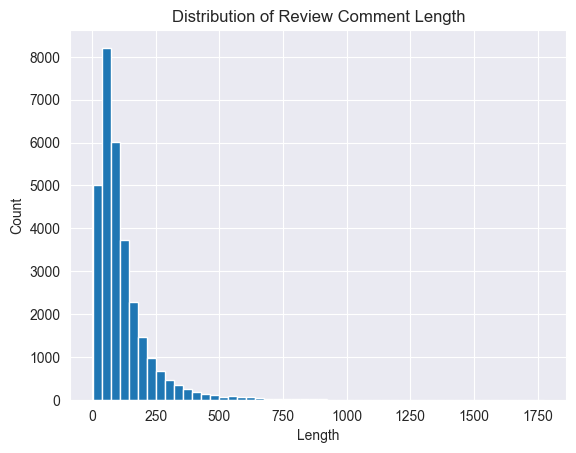

In [33]:
plt.figure()
df["msg_len"].hist(bins=50)
plt.title("Distribution of Review Comment Length")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

8. Розподіл змін у коді

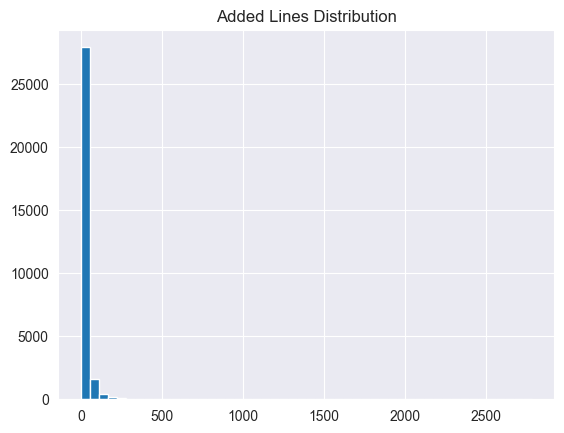

In [34]:
plt.figure()
df["added_lines"].hist(bins=50)
plt.title("Added Lines Distribution")
plt.show()

9. Топ репозиторії

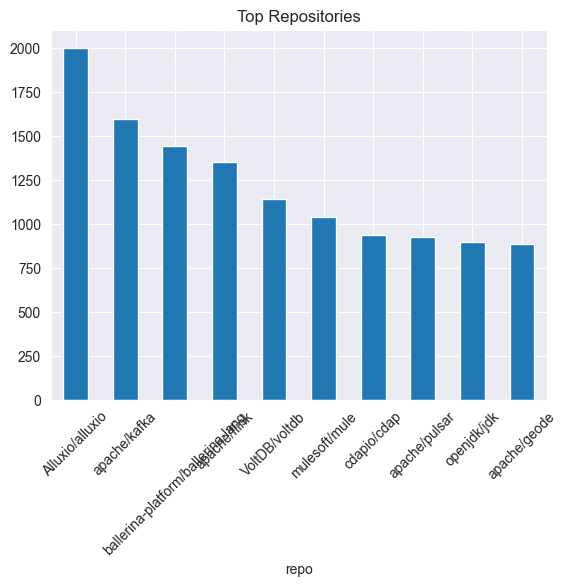

In [35]:
top_repos = df["repo"].value_counts().head(10)

plt.figure()
top_repos.plot(kind="bar")
plt.title("Top Repositories")
plt.xticks(rotation=45)
plt.show()

10. Топ ревʼюери

In [36]:
df["user_login"].value_counts().head(10)

user_login
calvinjia       405
gpang           341
aaudiber        333
trustin         291
chtyim          270
elrodro83       267
apc999          266
wu-sheng        238
nbradbury       213
guozhangwang    209
Name: count, dtype: int64

11. Аналіз часу

In [37]:
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")

df["year"] = df["created_at"].dt.year

df["year"].value_counts().sort_index()

year
1970    30230
Name: count, dtype: int64

12. Кореляції (важливо)

In [38]:
df[["msg_len", "added_lines", "removed_lines", "code_len"]].corr()

,msg_len,added_lines,removed_lines,code_len
msg_len,1.000000,0.009893,0.012478,0.066997
added_lines,0.009893,1.000000,0.221053,-0.052844
removed_lines,0.012478,0.221053,1.000000,0.037672
code_len,0.066997,-0.052844,0.037672,1.000000


13. Visualization

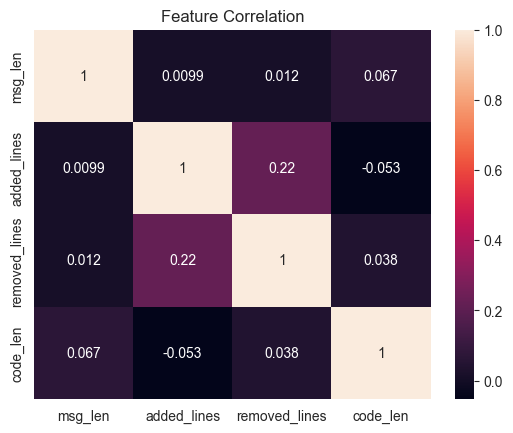

In [39]:
plt.figure()
sns.heatmap(
    df[["msg_len", "added_lines", "removed_lines", "code_len"]].corr(),
    annot=True
)
plt.title("Feature Correlation")
plt.show()

14. Приклади

випадкові коментарі

In [41]:
df["msg"].sample(5)

9301     maybe `persistFileTest` after method name change?
865      I don't think it is a state. `checkNotNull` co...
17107    Can we collapse this if statement with the nex...
23958    The returned value is just ignored? If that's ...
26042      I'm a big fan of `<b><i>` for this :-) but LGTM
Name: msg, dtype: str

випадковий patch

In [42]:
print(df["patch"].sample(1).iloc[0])

@@ -99,6 +104,20 @@ public void tearDown() {
         }
     }
 
+    @Test
+    public void testPluggableParser() {
+        TableEnvironmentInternal tableEnvInternal = (TableEnvironmentInternal) tableEnv;
+        Parser parser = tableEnvInternal.getParser();
+        // hive dialect should use HiveParser
+        assertTrue(parser instanceof HiveParser);
+        // execute some sql and verify the parser instance is reused
+        tableEnvInternal.executeSql("show databases");
+        assertSame(parser, tableEnvInternal.getParser());
+        // switching dialect will result in a new parser
+        tableEnvInternal.getConfig().setSqlDialect(SqlDialect.DEFAULT);
+        assertNotSame(parser, tableEnvInternal.getParser());


15. Простий insight (дуже корисно)

In [43]:
df["has_comment"] = df["msg_len"] > 0

df["has_comment"].value_counts()

has_comment
True    30230
Name: count, dtype: int64

Streaming аналіз

In [45]:
java_count = 0
total_comments = 0
total_added = 0

with open(FILE_PATH, "r", encoding="utf-8") as f:
    for line in tqdm(f):
        row = json.loads(line)

        if row.get("lang") == "java":
            java_count += 1

            msg = str(row.get("msg", ""))
            patch = str(row.get("patch", ""))

            if msg:
                total_comments += 1

            total_added += patch.count("+")

print("Java rows:", java_count)
print("Rows with comments:", total_comments)
print("Total added lines:", total_added)

141259it [04:33, 515.69it/s] 

Java rows: 30230
Rows with comments: 30230
Total added lines: 534370
